In [301]:
import pandas as pd

# Load data
df = pd.read_csv("../../data/50_Startups.csv")
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [314]:
X = df.loc[: ,["R&D Spend", "Administration",	"Marketing Spend", "State"]]
y = df["Profit"]

X, y

(    R&D Spend  Administration  Marketing Spend       State
 0   165349.20       136897.80        471784.10    New York
 1   162597.70       151377.59        443898.53  California
 2   153441.51       101145.55        407934.54     Florida
 3   144372.41       118671.85        383199.62    New York
 4   142107.34        91391.77        366168.42     Florida
 5   131876.90        99814.71        362861.36    New York
 6   134615.46       147198.87        127716.82  California
 7   130298.13       145530.06        323876.68     Florida
 8   120542.52       148718.95        311613.29    New York
 9   123334.88       108679.17        304981.62  California
 10  101913.08       110594.11        229160.95     Florida
 11  100671.96        91790.61        249744.55  California
 12   93863.75       127320.38        249839.44     Florida
 13   91992.39       135495.07        252664.93  California
 14  119943.24       156547.42        256512.92     Florida
 15  114523.61       122616.84        26

In [315]:
numeric_features = ["R&D Spend", "Administration",	"Marketing Spend"]
categorical_features = ["State"]

In [324]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, Normalizer

preprocessor = ColumnTransformer(
    [
        ("num", Normalizer(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

standard_scaler = StandardScaler()
X_transformed = preprocessor.fit_transform(X)
categorical_features = preprocessor.named_transformers_["cat"].get_feature_names_out().tolist()
columns = numeric_features + categorical_features
X_transformed = pd.DataFrame(X_transformed, columns=columns)
X_transformed

ValueError: A given column is not a column of the dataframe

In [317]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=10)

In [318]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [319]:
y_pred = model.predict(X_test)
y_pred

residuals = y_test - y_pred
residuals

37      775.412159
23    -1437.911449
44     -622.147580
42      713.278574
47    -5092.396940
20     2170.433348
3     10725.709965
30     -719.472541
7     -4720.652659
6     -2713.112462
Name: Profit, dtype: float64

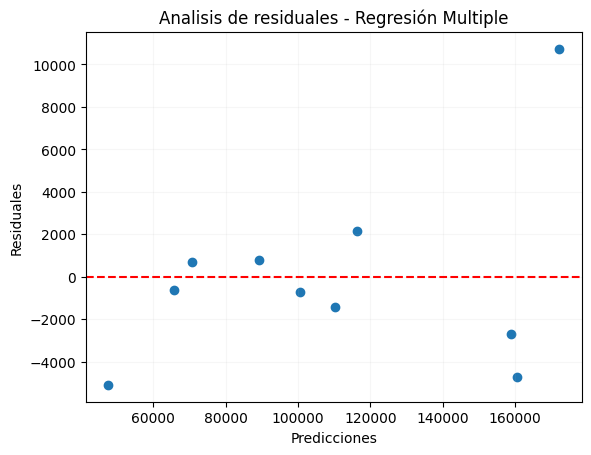

In [320]:
import matplotlib.pyplot as plt

plt.scatter(x=y_pred, y=residuals)
plt.xlabel("Predicciones")
plt.ylabel("Residuales")
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Analisis de residuales - Regresión Multiple")
plt.grid(True, alpha=0.1)
plt.show()

In [322]:
import numpy as np
import statsmodels.api as sm 

X_transformed = sm.add_constant(X_transformed)

X_opt = X_transformed.iloc[:, [0, 1, 2, 3, 4, 5]]
reg_OLS = sm.OLS(endog = y, exog = X_opt).fit()
reg_OLS.summary()

X_opt = X_transformed.iloc[:, [0, 1, 2, 3]]
reg_OLS = sm.OLS(endog = y, exog = X_opt).fit()
reg_OLS.summary()

X_opt = X_transformed.iloc[:, [0, 1, 3]]
reg_OLS = sm.OLS(endog = y, exog = X_opt).fit()
reg_OLS.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Profit   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     450.8
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           2.16e-31
Time:                        12:45:21   Log-Likelihood:                -525.54
No. Observations:                  50   AIC:                             1057.
Df Residuals:                      47   BIC:                             1063.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             1.12e+05   1295.556     86.459      0.000    1.09e+05    1.15e+05
R&D Spend         3.62e+04   1878.872     19.266      0.000    3.24e+04       4e+04
Marketing Spend  3620.6842   1878.872      1.927      0.060    -159.118    7400.487
==============================================================================
Omnibus:                       14.677   Durbin-Watson:                   1.257
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               21.161
Skew:                          -0.939   Prob(JB):                     2.54e-05
Kurtosis:                       5.575   Cond. No.                         2.50
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

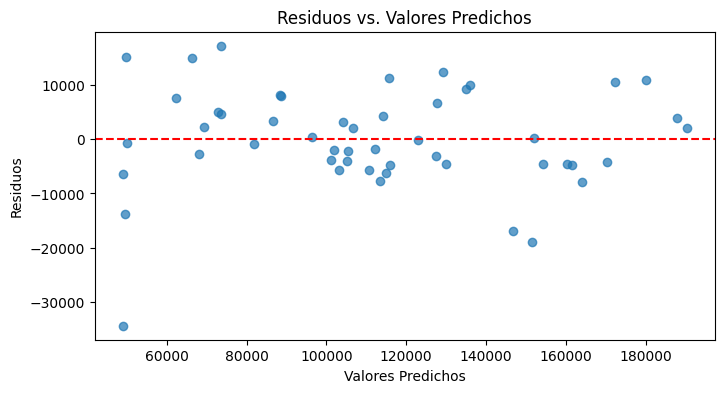

In [321]:
plt.figure(figsize=(8,4))
plt.scatter(reg_OLS.fittedvalues, reg_OLS.resid, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')  # Línea en 0
plt.title('Residuos vs. Valores Predichos')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.show()